### This notebook covers up extracting useful feature from our dataset (ik looks ai but this is my writting lol) to useful things for our model

---

#### importing the clean Dataset

In [6]:
import pandas as pd

df = pd.read_csv(
    "../data/btc_usd_daily.csv", 
    skiprows=[1, 2]
)


df = df.rename(columns={"Price": "Date"})

In [7]:
df.set_index("Date", inplace=True)

df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200


---

# Feature 1: Price Change

## What is Price Change?

Price Change measures how much the asset moved during a candle.

It captures the difference between the opening and closing prices.

Positive values indicate bullish candles.

Negative values indicate bearish candles.

---

## Formula

Change = Close − Open

---

## Why are we using it?

Price movement inside a candle provides a simple measure of market sentiment.

Large positive changes may indicate strong buying pressure.

Large negative changes may indicate selling pressure.

This feature can help the model understand short-term trends.

---

## Limitations

A single candle does not describe the overall trend.

Large candles may occur because of news or sudden volatility.

Therefore, Price Change should be combined with other indicators.

In [8]:
df["Change"] = df["Close"] - df["Open"]

df[["Open", "Close", "Change"]].head()

,Open,Close,Change
Date,,,
2020-01-02,71.344062,72.333885,0.989823
2020-01-03,71.563205,71.630638,0.067433
2020-01-06,70.754021,72.201416,1.447395
2020-01-07,72.211049,71.861847,-0.349202
2020-01-08,71.565621,73.017838,1.452216


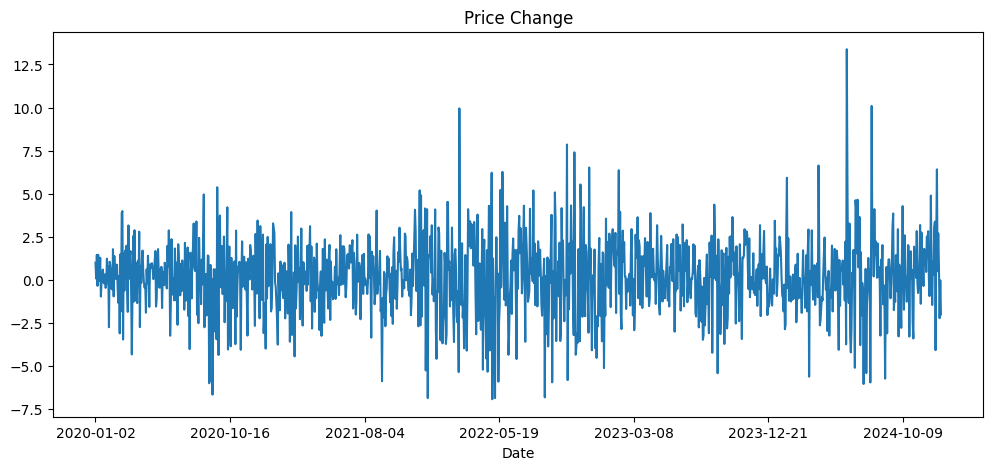

In [9]:
import matplotlib.pyplot as plt

df["Change"].plot(figsize=(12, 5))

plt.title("Price Change")

plt.show()

#### it should answer this
1. Are positive candles more common?
-> No, Looks like negatives are more common

2. Are there extreme spikes?
-> Yes there are a lot of extreme spikes

3. Does Apple have periods of high volatility(measures the rate and magnitude of price changes)?
-> yes it's highly volatile

- High Volatility: The price swings up and down rapidly and widely (e.g., during market panics, earnings reports, or product launches).
- Low Volatility: The price is stable and moves in small, steady increments.
- "Periods of high volatility" refers to clusters in time where the price was highly unstable (e.g., during the March 2020 COVID-19 crash or late 2022 tech selloff).

---
# Feature 2: Percentage Return

## What is Percentage Return?

Percentage Return measures how much the price changed relative to the previous candle.

Unlike raw price changes, returns are normalized.

A $100 increase means different things for assets priced at $1,000 and $100,000.

---

## Formula

Return = (Current Close − Previous Close) / Previous Close

---

## Why are we using it?

Machine learning models perform better when features are scale-independent.

Returns allow us to compare market behavior across different time periods.

Returns are also used for volatility and risk calculations.

---

## Limitations

Returns only measure short-term movement.

They do not capture momentum or long-term trends.

In [10]:
df["Return"] = df["Close"].pct_change()

df[["Close", "Return"]].head()

,Close,Return
Date,,
2020-01-02,72.333885,NaN
2020-01-03,71.630638,-0.009722
2020-01-06,72.201416,0.007968
2020-01-07,71.861847,-0.004703
2020-01-08,73.017838,0.016086


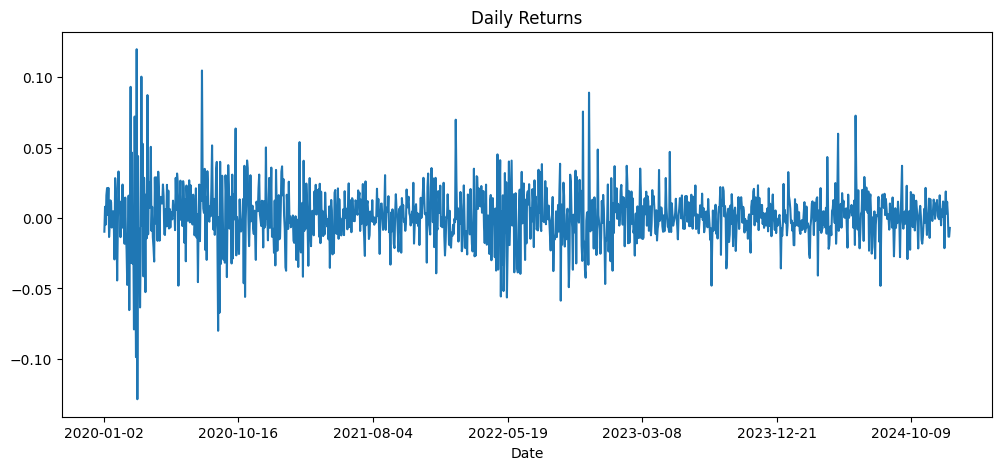

In [11]:
df["Return"].plot(figsize=(12, 5))

plt.title("Daily Returns")

plt.show()

--- 

# Feature 3: Volume Change

## What is Volume Change?

Volume Change measures how trading activity changes over time.

It tells us whether participation in the market is increasing or decreasing.

---

## Formula

Volume Change = (Current Volume − Previous Volume) / Previous Volume

---

## Why are we using it?

Price movements supported by large trading volume are generally more reliable.

Increasing volume may indicate stronger market conviction.

---

## Limitations

Volume spikes may be caused by one-time events and do not always indicate trends.

In [12]:
df["Volume_Change"] = df["Volume"].pct_change()

df[["Volume", "Volume_Change"]].head()

,Volume,Volume_Change
Date,,
2020-01-02,135480400,NaN
2020-01-03,146322800,0.080029
2020-01-06,118387200,-0.190918
2020-01-07,108872000,-0.080374
2020-01-08,132079200,0.213160


---

# Feature 4: Momentum

## What is Momentum?

Momentum measures how much the price has changed over a fixed time window.

It helps determine whether the market is accelerating upward or downward.

---

## Formula

Momentum = Current Close − Close n periods ago

For this project:

Momentum = Current Close − Close 5 days ago

---

## Why are we using it?

Strong trends often continue for some time.

Momentum helps capture this continuation effect.

Positive momentum indicates bullish behavior.

Negative momentum indicates bearish behavior.

---

## Limitations

Momentum performs poorly in sideways markets.

In [13]:
df["Momentum_5"] = df["Close"] - df["Close"].shift(5)

In [14]:
df[["Close", "Momentum_5"]].head(10)

,Close,Momentum_5
Date,,
2020-01-02,72.333885,NaN
2020-01-03,71.630638,NaN
2020-01-06,72.201416,NaN
2020-01-07,71.861847,NaN
2020-01-08,73.017838,NaN
2020-01-09,74.568794,2.234909
2020-01-10,74.737358,3.106720
2020-01-13,76.334091,4.132675
2020-01-14,75.303337,3.441490


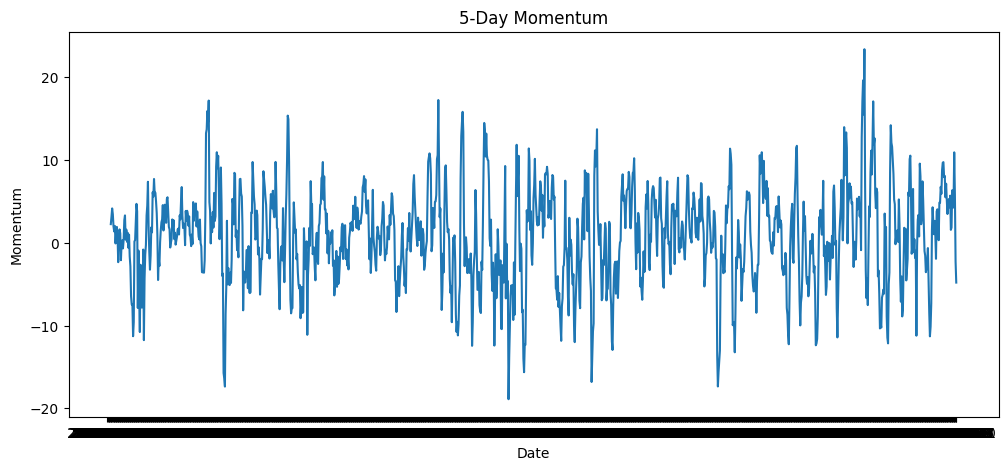

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(df.index, df["Momentum_5"])

plt.title("5-Day Momentum")
plt.xlabel("Date")
plt.ylabel("Momentum")

plt.show()

---

# Feature 5: Moving Average (MA)

## What is a Moving Average?

A Moving Average smooths out price fluctuations by averaging prices over a fixed period.

Instead of looking at today's price alone, it considers the average price of the last N candles.

---

## Formula

MA(n) = (P₁ + P₂ + ... + Pₙ) / n

For example:

MA(10) = Average of the last 10 closing prices.

---

## Why are we using it?

Moving averages help identify trends.

- Price above MA → bullish trend.
- Price below MA → bearish trend.

Short moving averages react quickly.

Long moving averages react slowly.

---

## Features used

For this project:

- MA_10
- MA_50

---

## Limitations

Moving averages lag behind the market because they rely on historical prices.

In [16]:
df["MA_10"] = df["Close"].rolling(window=10).mean()

df["MA_50"] = df["Close"].rolling(window=50).mean()

In [17]:
df[["Close", "MA_10", "MA_50"]].head(60)

,Close,MA_10,MA_50
Date,,,
2020-01-02,72.333885,NaN,NaN
2020-01-03,71.630638,NaN,NaN
2020-01-06,72.201416,NaN,NaN
2020-01-07,71.861847,NaN,NaN
2020-01-08,73.017838,NaN,NaN
2020-01-09,74.568794,NaN,NaN
2020-01-10,74.737358,NaN,NaN
2020-01-13,76.334091,NaN,NaN
2020-01-14,75.303337,NaN,NaN


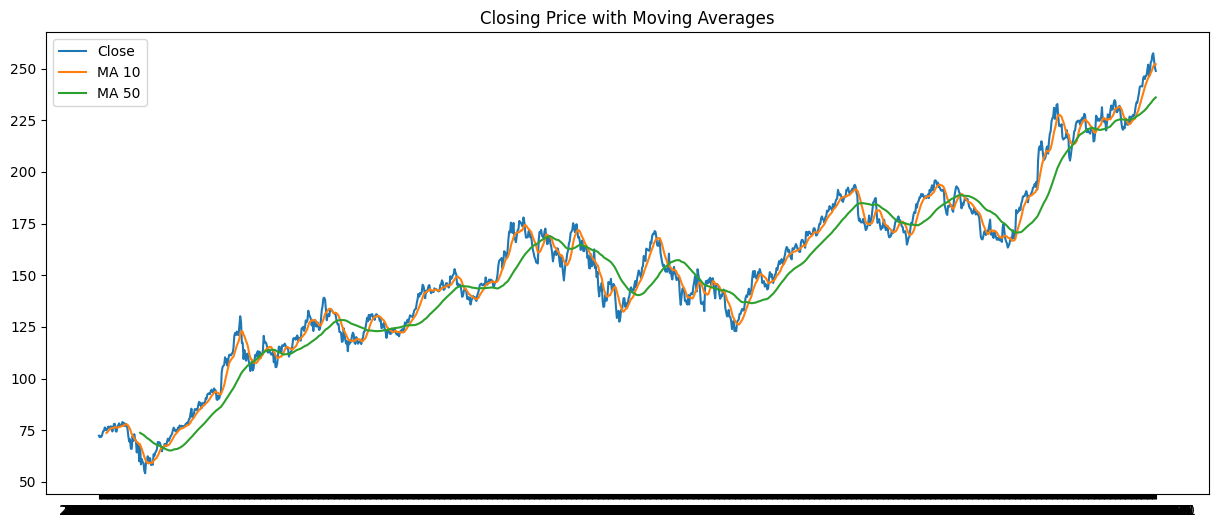

In [18]:
plt.figure(figsize=(15, 6))

plt.plot(df.index, df["Close"], label="Close")

plt.plot(df.index, df["MA_10"], label="MA 10")

plt.plot(df.index, df["MA_50"], label="MA 50")

plt.title("Closing Price with Moving Averages")

plt.legend()

plt.show()

observations:

1. Does MA_10 follow the price closely?
-> Yes it's much closer than MA_50

2. Does MA_50 react more slowly?
-> It has a large delay

4. Where do they cross?
-> In technical analysis, when two moving averages cross, it is called a crossover signal, indicating a shift in momentum and trend direction:

    Golden Cross (Bullish Crossover): When the fast line (MA_10) crosses above the slow line (MA_50). This indicates that short-term price momentum is accelerating upward relative to the long-term trend, suggesting it is a good time to buy.
    Death Cross (Bearish Crossover): When the fast line (MA_10) crosses below the slow line (MA_50). This indicates that short-term momentum is slowing down rapidly relative to the long-term trend, suggesting it is a good time to sell or stay out.



5. Are there large trends?
-> if the asset spends long, continuous periods moving in a clear direction (up or down), or if it just bounces around sideways (choppy/rangebound).

    Moving averages identify a strong trend when the lines slope steeply in one direction and the gap (spread) between MA_10 and MA_50 is wide and stable.

    YEs very distinct larger trends

---

# Feature 6: Volatility

## What is Volatility?

Volatility measures how much prices fluctuate over time.

High volatility means large price swings.

Low volatility means stable prices.

---

## Formula

Volatility = Standard Deviation(Returns)

For this project:

20-day rolling standard deviation.

---

## Why are we using it?

Volatility helps estimate market risk.

High volatility:

- Higher risk.
- Bigger moves.

Low volatility:

- Stable market.

---

## Limitations

Volatility measures movement magnitude, not direction.

In [19]:
df["Volatility"] = (
    df["Return"]
    .rolling(window=20)
    .std()
)

df[["Return", "Volatility"]].head(30)

,Return,Volatility
Date,,
2020-01-02,NaN,NaN
2020-01-03,-0.009722,NaN
2020-01-06,0.007968,NaN
2020-01-07,-0.004703,NaN
2020-01-08,0.016086,NaN
2020-01-09,0.021241,NaN
2020-01-10,0.002261,NaN
2020-01-13,0.021365,NaN
2020-01-14,-0.013503,NaN


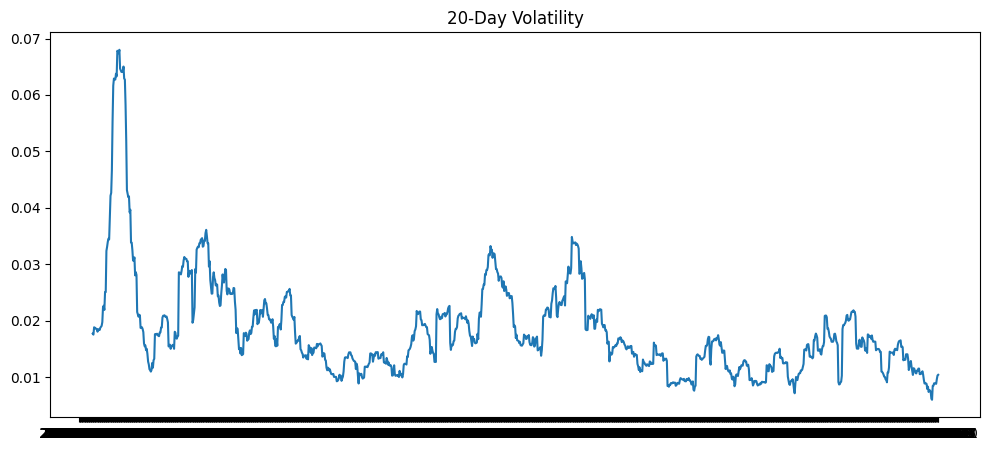

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(df.index, df["Volatility"])

plt.title("20-Day Volatility")

plt.show()

---
# Feature 7: RSI (Relative Strength Index)

## What is RSI?

RSI measures the strength of recent price movements.

It ranges from 0 to 100.

---

## Formula

RSI = 100 − (100 / (1 + RS))

where:

RS = Average Gain / Average Loss

---

## Interpretation

RSI > 70:

- Potentially overbought.

RSI < 30:

- Potentially oversold.

---

## Why are we using it?

RSI helps identify momentum and possible reversals.

---

## Limitations

RSI can remain overbought or oversold during strong trends.

In [21]:
from ta.momentum import RSIIndicator

rsi = RSIIndicator(close=df["Close"])

df["RSI"] = rsi.rsi()

df[["Close", "RSI"]].head(20)

,Close,RSI
Date,,
2020-01-02,72.333885,NaN
2020-01-03,71.630638,NaN
2020-01-06,72.201416,NaN
2020-01-07,71.861847,NaN
2020-01-08,73.017838,NaN
2020-01-09,74.568794,NaN
2020-01-10,74.737358,NaN
2020-01-13,76.334091,NaN
2020-01-14,75.303337,NaN


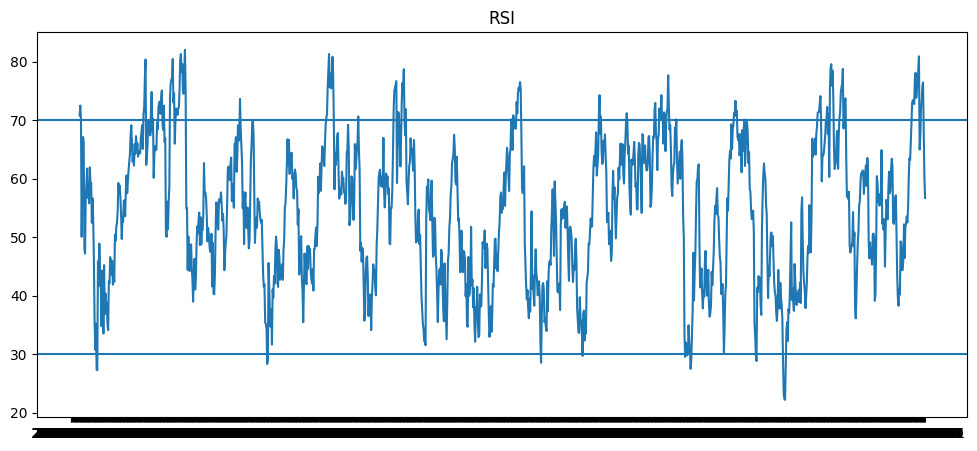

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(df.index, df["RSI"])

plt.axhline(70)

plt.axhline(30)

plt.title("RSI")

plt.show()

---

# Feature 8: MACD (Moving Average Convergence Divergence)

## What is MACD?

MACD measures the relationship between short-term and long-term trends.

---

## Formula

MACD = EMA(12) − EMA(26)

Signal = EMA(MACD, 9)

---

## Components

- MACD line.
- Signal line.
- Histogram.

---

## Interpretation

MACD crossing above Signal:

- Bullish.

MACD crossing below Signal:

- Bearish.

---

## Why are we using it?

MACD combines trend and momentum into a single indicator.

---

## Limitations

MACD may generate false signals in sideways markets.

In [23]:
from ta.trend import MACD

macd = MACD(close=df["Close"])

df["MACD"] = macd.macd()

df["MACD_Signal"] = macd.macd_signal()

df["MACD_Hist"] = macd.macd_diff()

df[
    [
        "MACD",
        "MACD_Signal",
        "MACD_Hist"
    ]
].head(40)

,MACD,MACD_Signal,MACD_Hist
Date,,,
2020-01-02,NaN,NaN,NaN
2020-01-03,NaN,NaN,NaN
2020-01-06,NaN,NaN,NaN
2020-01-07,NaN,NaN,NaN
2020-01-08,NaN,NaN,NaN
2020-01-09,NaN,NaN,NaN
2020-01-10,NaN,NaN,NaN
2020-01-13,NaN,NaN,NaN
2020-01-14,NaN,NaN,NaN


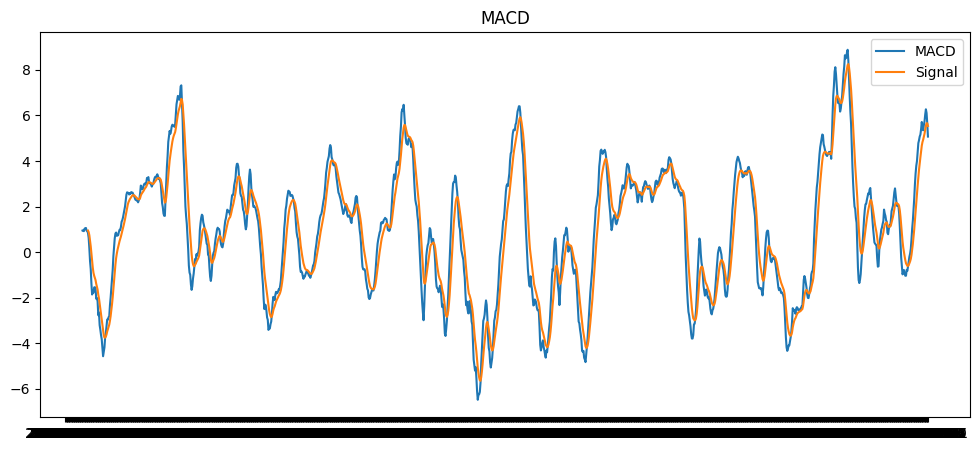

In [24]:
plt.figure(figsize=(12, 5))

plt.plot(
    df.index,
    df["MACD"],
    label="MACD"
)

plt.plot(
    df.index,
    df["MACD_Signal"],
    label="Signal"
)

plt.legend()

plt.title("MACD")

plt.show()

### Celeaning the data again

#### After Feature creation of all features we notice a lot of Nan because of our calculation best thing to do is to drop them

In [25]:
df.isna().sum()

Close             0
High              0
Low               0
Open              0
Volume            0
Change            0
Return            1
Volume_Change     1
Momentum_5        5
MA_10             9
MA_50            49
Volatility       20
RSI              13
MACD             25
MACD_Signal      33
MACD_Hist        33
dtype: int64

In [26]:
df = df.dropna()

df.shape

(1209, 16)

In [27]:
df.isna().sum()

Close            0
High             0
Low              0
Open             0
Volume           0
Change           0
Return           0
Volume_Change    0
Momentum_5       0
MA_10            0
MA_50            0
Volatility       0
RSI              0
MACD             0
MACD_Signal      0
MACD_Hist        0
dtype: int64

# Categorizing Noise vs. Useful Features

Understanding the characteristics of our features is crucial for building a strong predictive target for our machine learning model.

---

### 1. How to Think About This: The Noise vs. Lag Trade-Off

Every technical indicator or feature is a way of processing raw price data. When you select or design features, you are adjusting a slider between two extremes:

*   **Short-Term / Raw Features** (e.g., *Daily Price Change*, *MA_10*, *5-Day Momentum*):
    *   **Pros:** They react immediately to new information (low lag).
    *   **Cons:** They contain a lot of random day-to-day fluctuations (high noise).
*   **Long-Term / Smoothed Features** (e.g., *MA_50*, *Volatility*):
    *   **Pros:** They filter out random daily noise to highlight the big-picture trend.
    *   **Cons:** They are slow to react and lag behind the current price.

---

### 2. Feature Analysis Questions & Answers

#### **Q1: Which feature follows price most closely?**
> **Answer:** **`MA_10`** (or raw price changes).
> 
> * **How to find it:** Plot the `Close` price, `MA_10`, and `MA_50` together. You will notice that the `MA_10` line closely hugs the `Close` price line, tracking almost all of its short-term peaks and valleys.

#### **Q2: Which reacts the slowest?**
> **Answer:** **`MA_50`** (50-day Moving Average).
> 
> * **How to find it:** Look at the chart during sudden price crashes or spikes. The `MA_50` line continues in its original direction for days or weeks before gradually bending. This is because it averages a wider window of past data, making it heavy and slow to react.

#### **Q3: Which seems the noisiest?**
> **Answer:** **`Price Change` (Feature 1)** or **`Percentage Return` (Feature 2)**.
> 
> * **How to find it:** If you plot `Percentage Return`, you will see a graph resembling an EKG machine—spiking up and down rapidly above and below zero. This represents high-frequency daily noise.

#### **Q4: Which one would you trust if you were trading?**
> **Answer:** **A combination of both (crossover), but `MA_50` for the trend.**
> 
> * **Why?** 
>   * Relying solely on **noisy** features (`Price Change` or `MA_10`) leads to getting *whipsawed* (constantly buying and selling on false breakout signals).
>   * Relying solely on the **slowest** feature (`MA_50`) means entering trades too late, leaving a significant portion of profit on the table.
>   * **Professional Approach:** Use **`MA_50`** to identify the overall *trend direction* (e.g., "only buy if the price is above the MA_50"), and use **`MA_10`** crossings to determine the *timing* of entries and exits.

---

### 3. Summary of Observations

*   **Closest to Price:** `MA_10` (reacts quickly, low lag).
*   **Slowest Reaction:** `MA_50` (smooths out the trend, high lag).
*   **Noisiest:** Daily raw features like `Price Change` and `Percentage Return` (frequent whipsaws).
*   **Most Trusted for Trading:** **`MA_50`** for determining trend direction, and the **crossover (`MA_10` crossing `MA_50`)** for trade execution.


In [28]:
# saving our features
import os

os.makedirs("../data", exist_ok=True)

df.to_csv(
    "../data/btc_features.csv",
    index=True
)

print("Feature dataset saved.")

Feature dataset saved.
